<a href="https://colab.research.google.com/github/Mehttap/Machine_Learning/blob/main/ReinforcementLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reinforcement Learning**

**Q Learning Algorithm**

Q Algoritması ile, pekiştirmeli öğrenme problemi olan 'uçurum yürüyüşü' ortamını çözelim.

Burada ajanımız, başlangıç noktasından hedefe ulaşmaya çalışırken, uçurum bölgelerinden kaçınmayı deneyimleyerek öğrenir. Her adımda aldığı ödüller ve cezalar sayesinde en iyi aksiyonları seçmeyi zamanla keşfeder ve Q tablosunu güncelleyerek optimal politika geliştirmeye çalışır. Bu örnekle keşif-sömürü dengesi, ödül fonksiyonu ve değer güncellemesi kavramlarını görsel bir ortam üzerinden anlayalım.

In [1]:
#Modülleri Yükleyelim

import numpy as np
import matplotlib.pyplot as plt

In [11]:
class QOgrenci:
  def __init__(self, durum_sayisi, aksiyon_sayisi):
    self.EPSILON =0.1
    self.ALPHA = 0.85
    self.GAMMA = 0.99
    self.aksiyon_sayisi = aksiyon_sayisi
    self.Q = np.zeros([durum_sayisi, self.aksiyon_sayisi])

  def aksiyonSec(self, durum):
    #epsilon-greedy stratejisi
    if np.random.binomial(1, self.EPSILON)== 1:
      return np.random.choice(self.aksiyon_sayisi)
    else:
      return np.argmax(self.Q[durum, :])

  def ogren(self, durum, aksiyon, odul, sonraki_durum):
    self.Q[durum, aksiyon] += self.ALPHA * (
        odul + self.GAMMA * np.max(self.Q[sonraki_durum, :]) - self.Q[durum, aksiyon]
    )

  def kesfiAzalt(self, i):
    self.EPSILON /= (i + 1)

class UcurumYuruyusu:
  def __init__(self, yukseklik, genislik):
    self.yukseklik= yukseklik
    self.genislik = genislik
    self.gozlem_uzayi = self.yukseklik * self.genislik
    self.aksiyon_uzayi = ["Y", "A", "S", "D"] #yukarı,aşağı,sol,sağ
    self.aksiyon_sayisi =len(self.aksiyon_uzayi)

    self.mevcut_konum = [self.yukseklik -1,0]

    self.ortam = np.array(range(self.gozlem_uzayi), dtype='U16').reshape(self.yukseklik, self.genislik)
    self.haritalayici = np.array(range(self.gozlem_uzayi)).reshape(self.yukseklik, self.genislik)
    self.ortam[:,:] = " "
    self.ortam[self.yukseklik -1, self.genislik -1] = "X" #uçurum
    self.ortam[self.yukseklik -1, 0] = "*" #başlangıç
    self.ortam[self.yukseklik -1, self.genislik -1] = "G" #hedef

  def adim(self,aksiyon):
    #önceki konumu temizle
    self.ortam[self.mevcut_konum[0], self.mevcut_konum[1]]= " "

    #yeni konumu hesapla
    if (self.aksiyon_uzayi[aksiyon]== "Y" and self.mevcut_konum[0]> 0):
      self.mevcut_konum[0] -= 1
    elif (self.aksiyon_uzayi[aksiyon]== "A" and self.mevcut_konum[0] < self.yukseklik -1):
      self.mevcut_konum[0] += 1
    elif (self.aksiyon_uzayi[aksiyon]== "S" and self.mevcut_konum[1] > 0):
      self.mevcut_konum[1] -= 1
    elif (self.aksiyon_uzayi[aksiyon]== "D" and self.mevcut_konum[1] < self.genislik -1):
      self.mevcut_konum[1] += 1

    sonraki_durum = self.haritalayici[self.mevcut_konum[0], self.mevcut_konum[1]]

    #ödül hesaplama
    odul= -100 if (self.ortam[self.mevcut_konum[0], self.mevcut_konum[1]]== "X") else -1

    #oyun bitti mi?
    bitti = (self.ortam[self.mevcut_konum[0], self.mevcut_konum[1]] in ["X", "G"])

    #yeni konumu çiz
    if not bitti:
      self.ortam[self.mevcut_konum[0], self.mevcut_konum[1]]= "*"

    return sonraki_durum, odul, bitti, ""

  def sifirla (self):
    self.ortam[self.yukseklik -1, 0] = "*"
    self.mevcut_konum = [self.yukseklik -1,0]
    return self.haritalayici[self.yukseklik -1,0]

  def goster(self):
    print(self.ortam)

if __name__ == "__main__":
  ortam= UcurumYuruyusu(4,12)

  bolum_sayisi= 200
  adim_sayisi=100

  ajan = QOgrenci(ortam.gozlem_uzayi, ortam.aksiyon_sayisi)

  toplam_odul = np.zeros(bolum_sayisi)

  for i in range(bolum_sayisi):
    durum = ortam.sifirla()

    for j in range(adim_sayisi):
      ortam.goster()

      aksiyon = ajan.aksiyonSec(durum)

      sonraki_durum, odul, bitti, bilgi = ortam.adim(aksiyon)

      ajan.ogren(durum, aksiyon, odul, sonraki_durum)

      toplam_odul[i] += odul
      durum = sonraki_durum

      if bitti:
        ajan.kesfiAzalt(i)
        break


Görüntülenen çıkış son 5000 satıra kısaltıldı.
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' '*' ' ' ' ' ' ' ' ' ' ' ' ' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' '*' ' ' ' ' ' ' ' ' ' ' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' '*' ' ' ' ' ' ' ' ' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' '*' ' ' ' ' ' ' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' '

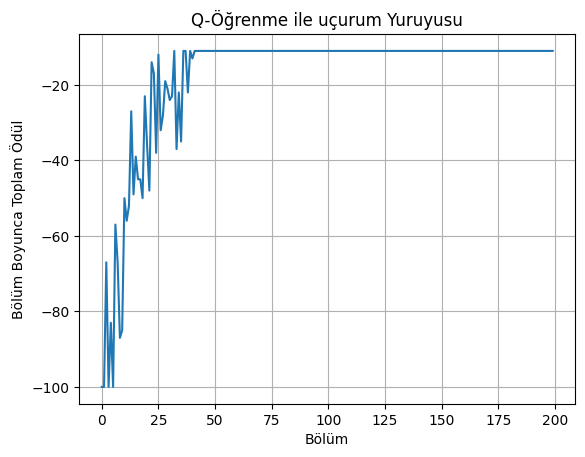

In [15]:
x = np.arange(0, bolum_sayisi, 1)
y = np.array(toplam_odul)
plt.plot(x, y)
plt.xlabel("Bölüm")
plt.ylabel("Bölüm Boyunca Toplam Ödül")
plt.title("Q-Öğrenme ile uçurum Yuruyusu")
plt.grid(True)
plt.show()